<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/%EB%B2%BD_%EA%B7%A0%EC%97%B4_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving 벽균열.zip to 벽균열.zip


In [2]:
# 압축 풀기 (출력 보이게)
!unzip "/content/벽균열.zip" -d /content/crack_dataset

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/crack_dataset/3/train/normal/03146.jpg  
  inflating: /content/crack_dataset/3/train/normal/03443.jpg  
  inflating: /content/crack_dataset/3/train/crack/02461.jpg  
  inflating: /content/crack_dataset/3/train/crack/06153.jpg  
  inflating: /content/crack_dataset/3/train/crack/02915.jpg  
  inflating: /content/crack_dataset/3/train/crack/02574.jpg  
  inflating: /content/crack_dataset/3/train/normal/03218.jpg  
  inflating: /content/crack_dataset/3/train/normal/03331.jpg  
  inflating: /content/crack_dataset/3/train/normal/03294.jpg  
  inflating: /content/crack_dataset/3/train/crack/05589.jpg  
  inflating: /content/crack_dataset/3/train/normal/03117.jpg  
  inflating: /content/crack_dataset/3/train/crack/02191.jpg  
  inflating: /content/crack_dataset/3/train/crack/02045.jpg  
  inflating: /content/crack_dataset/3/train/crack/05938.jpg  
  inflating: /content/crack_dataset/3/train/normal/03168.jpg  
  inflating: /content/crack

In [3]:
!ls /content/crack_dataset

3


In [4]:
!ls /content/crack_dataset/3

test  train  val


In [5]:
!ls /content/crack_dataset/3/test

crack  normal


In [6]:
# 필수 Package import
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models

In [7]:
# 이미지를 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """지정된 경로의 이미지를 최대 4개까지 출력합니다."""
  plt.figure(figsize=(12, 3))
  for i, image_path in enumerate(image_paths[:max_images]):
    img = plt.imread(image_path)
    plt.subplot(1, max_images, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
  plt.show()

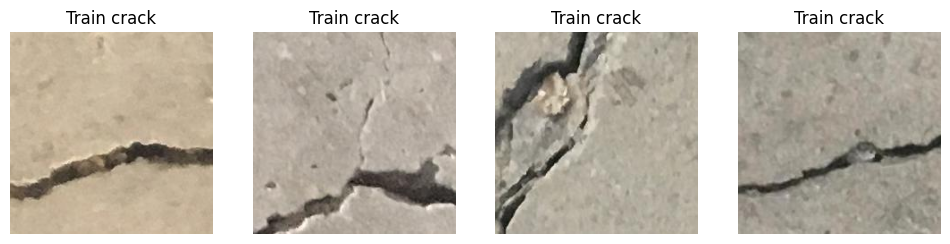

Train crack 총 이미지 수:17650


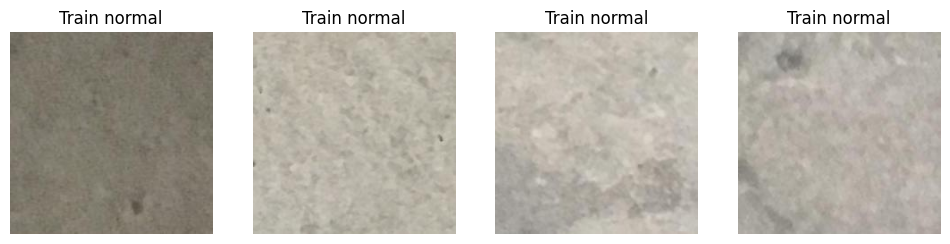

Train normal 총 이미지 수:17900


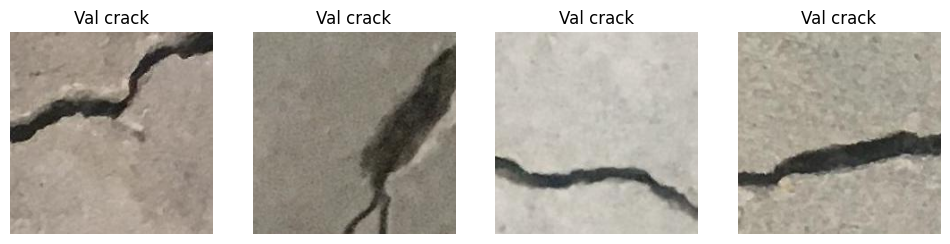

Val crack 총 이미지 수:1600


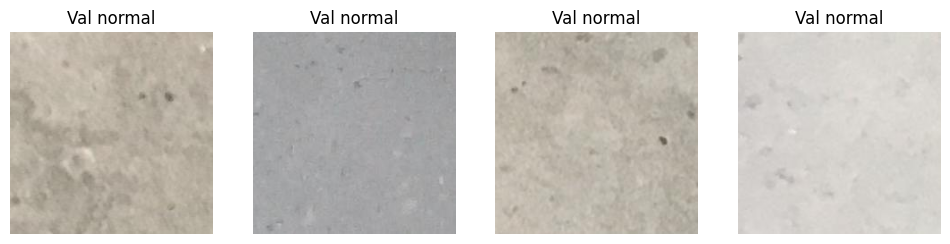

Val normal 총 이미지 수:1700


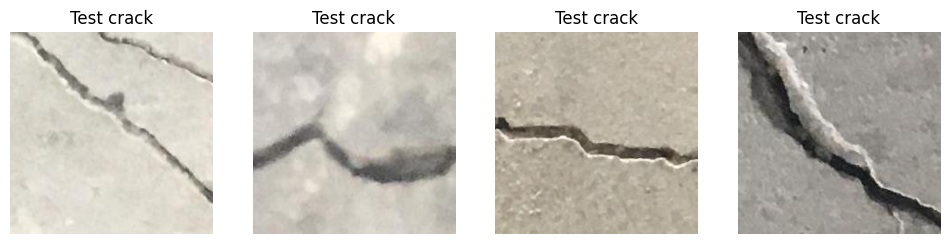

Test crack 총 이미지 수:100


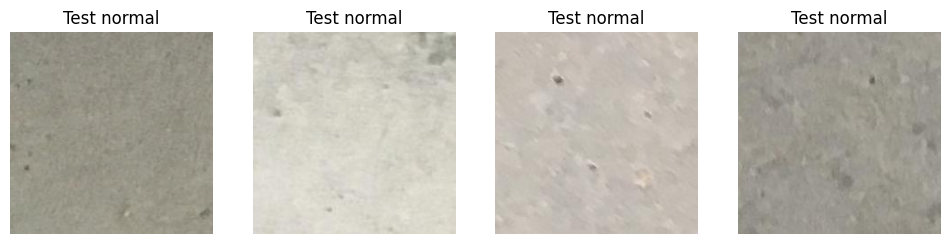

Test normal 총 이미지 수:100


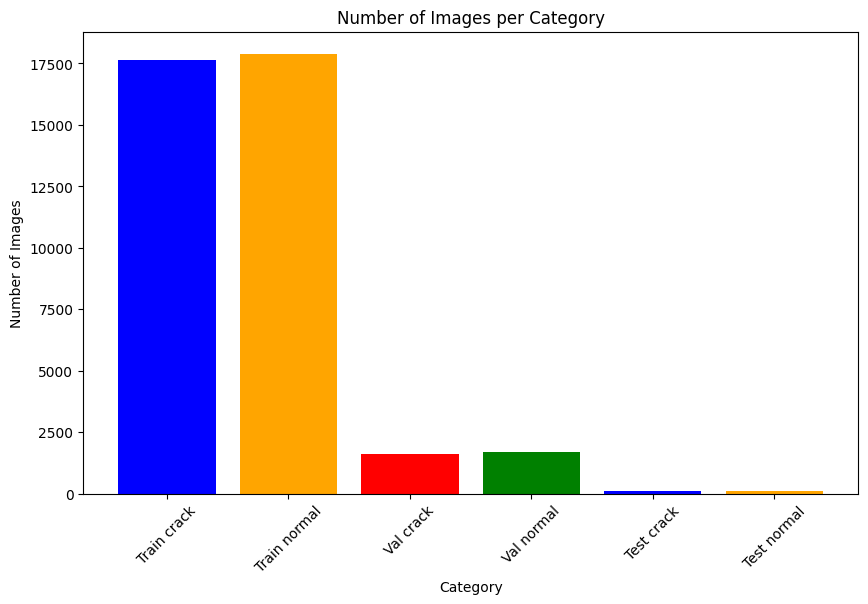

In [8]:
# 이미지와 바 그래프 출력
categories = ['Train crack', 'Train normal', 'Val crack', 'Val normal','Test crack', 'Test normal']

for category in categories:
  image_paths = glob.glob(f'/content/crack_dataset/3/{category.lower().replace(" ","/")}/*')
  display_images(image_paths, category)
  print(f"{category} 총 이미지 수:{len(image_paths)}")


# 바 그래프 생성
plt.figure(figsize=(10,6))
plt.bar(categories, [len(glob.glob(f'/content/crack_dataset/3/{category.lower().replace(" ","/")}/*')) for category in categories], color=["blue", "orange", "red","green"])
plt.title('Number of Images per Category')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [9]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.Resize((224, 224)), # 이미지 크기 조정
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 정규화
])

# 데이터셋 로드 및 데이터 로더 생성
train_dataset = ImageFolder('/content/crack_dataset/3/train', transform=transform)
val_dataset = ImageFolder('/content/crack_dataset/3/val', transform=transform)

In [10]:
from torch.utils.data import SubsetRandomSampler
import numpy as np

# 데이터셋 인덱스를 생성
num_of_train = 35550
num_of_val = 3300
train_indices = list(range(num_of_train))
val_indices = list(range(num_of_val))

# 200개의 무작위 샘플 선택
np.random.shuffle(train_indices)
train_subset_indices = train_indices[:200]

np.random.shuffle(val_indices)
val_subset_indices = val_indices[:20]

# 사용자 정의 Sampler 생성
train_sampler = SubsetRandomSampler(train_subset_indices)
val_sampler = SubsetRandomSampler(val_subset_indices)

# DataLoader에 Sampler 지정
train_loader = DataLoader(dataset=train_dataset, batch_size=8, sampler=train_sampler)
val_loader = DataLoader(dataset=val_dataset, batch_size=8, sampler=val_sampler)

In [11]:
# VGG 모델 로드 및 네트워크 구조 확인
net = models.vgg19(pretrained=True)
net

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 122MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [12]:
# 모델의 모든 파라미터를 고정
for param in net.parameters():
  param.requires_grad = False

In [13]:
# classifier의 마지막 레이블 Binary Classification Task에 맞게 교체하고, 이 레이어의 파라미터는 학습 가능하도록 설정
net.classifier[6] = nn.Linear(4096, 2)
net.classifier[6].requires_grad = True

In [14]:
# 손실 함수
criterion = nn.CrossEntropyLoss()

In [15]:
import torch.optim as optim

def train_model(optimizer_name, net, train_loader, val_loader, criterion, num_epochs=20):
  # optimizer 설정
  if optimizer_name == 'SGD':
    optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
  elif optimizer_name == 'Adam':
    optimizer = optim.Adam(net.parameters(), lr=0.001, betas=(0.9, 0.999))
  elif optimizer_name == 'RAdam':
    optimizer = optim.RAdam(net.parameters(), lr=0.001, betas=(0.9, 0.999))
  else:
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")


  # 학습/검증 손실과 검증 정확도를 저장할 리스트
  train_losses = []
  val_losses = []
  val_accuracies = []

  for epoch in range(num_epochs):
    net.train() # 1. 모델을 학습 모드로 설정
    running_loss = 0.0  # 에포크 마다 손실 누적할 변수 초기화
    for i, data in enumerate(train_loader): # 2. 학습 데이터 배치(batch) 단위로 반복
      inputs, labels = data               # 배치에서 입력(x), 정답(y) 분리
      optimizer.zero_grad()               # 3. 이전 배치에서 계산된 기울기 (gradient) 초기화
      outputs = net(inputs)               # 4. 모델에 입력을 넣어 예측값 계산 (forward propagation)
      loss = criterion(outputs, labels) # 5. 예측값과 정답을 비교해 손실(loss) 계산
      loss.backward() # 6. 역전파: 각 파라미터의 기울기 계산
      optimizer.step() # 7. 옵티마이저가 기울기를 바탕으로 파라미터 업데이트
      running_loss += loss.item() # 현재 배치의 손실 값을 누적

    # 매 에포크마다 평균 학습 손실 계산
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # 검증 손실 계산
    val_loss = 0.0
    net.eval() # 모델을 평가 모드로 설정
    correct = 0
    total = 0
    with torch.no_grad():     # 1. 검증 단계에서는 기울기(gradient) 계산 안 함 -> 메모리, 속도 절약
      for inputs, labels in val_loader:   # 2. 검증 데이터셋에서 배치 단위로 꺼내오기
        outputs = net(inputs)         # 3. 모델에 입력을 넣어 예측값 얻기
        _, predicted = torch.max(outputs, 1) # 4. 가장 높은 확률의 클래스를 예측값으로 선택
        total += labels.size(0)         # 5. 전체 샘플 수 누적
        correct += (predicted == labels).sum().item() # 6. 맞춘 개수 누적
        loss = criterion(outputs, labels)
        val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    print(f'[{optimizer_name}] Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Validation Accuracy: {val_accuracy:.2f}%')

  return train_losses, val_losses, val_accuracies

In [18]:
train_losses_RAdam, val_losses_RAdam, val_accuracies_RAdam = train_model('RAdam', net, train_loader, val_loader, criterion)

[RAdam] Epoch 1, Train Loss: 0.144139, Val Loss: 0.176936, Validation Accuracy: 95.00%
[RAdam] Epoch 2, Train Loss: 0.131492, Val Loss: 0.168613, Validation Accuracy: 95.00%
[RAdam] Epoch 3, Train Loss: 0.130138, Val Loss: 0.115543, Validation Accuracy: 95.00%
[RAdam] Epoch 4, Train Loss: 0.122914, Val Loss: 0.109833, Validation Accuracy: 95.00%
[RAdam] Epoch 5, Train Loss: 0.102319, Val Loss: 0.102406, Validation Accuracy: 95.00%
[RAdam] Epoch 6, Train Loss: 0.093490, Val Loss: 0.098401, Validation Accuracy: 95.00%
[RAdam] Epoch 7, Train Loss: 0.077014, Val Loss: 0.100339, Validation Accuracy: 95.00%
[RAdam] Epoch 8, Train Loss: 0.082658, Val Loss: 0.087802, Validation Accuracy: 95.00%
[RAdam] Epoch 9, Train Loss: 0.074417, Val Loss: 0.147274, Validation Accuracy: 95.00%
[RAdam] Epoch 10, Train Loss: 0.065678, Val Loss: 0.155583, Validation Accuracy: 95.00%
[RAdam] Epoch 11, Train Loss: 0.073559, Val Loss: 0.088466, Validation Accuracy: 95.00%
[RAdam] Epoch 12, Train Loss: 0.060854, V

In [ ]:
# 초기화
net = models.vgg19(pretrained=True)
for param in net.parameters():
  param.requires_grad = False
net.classifier[6] = nn.Linear(4096, 2)
net.classifier[6].requires_grad = True

In [19]:
# Image load 및 tensor로 변환
def load_and_transform_image(image_path, transform):
  image = Image.open(image_path).convert('RGB')
  return transform(image).unsqueeze(0) # 이미지를 모델에 맞게 변환하고 배치 차원 추가

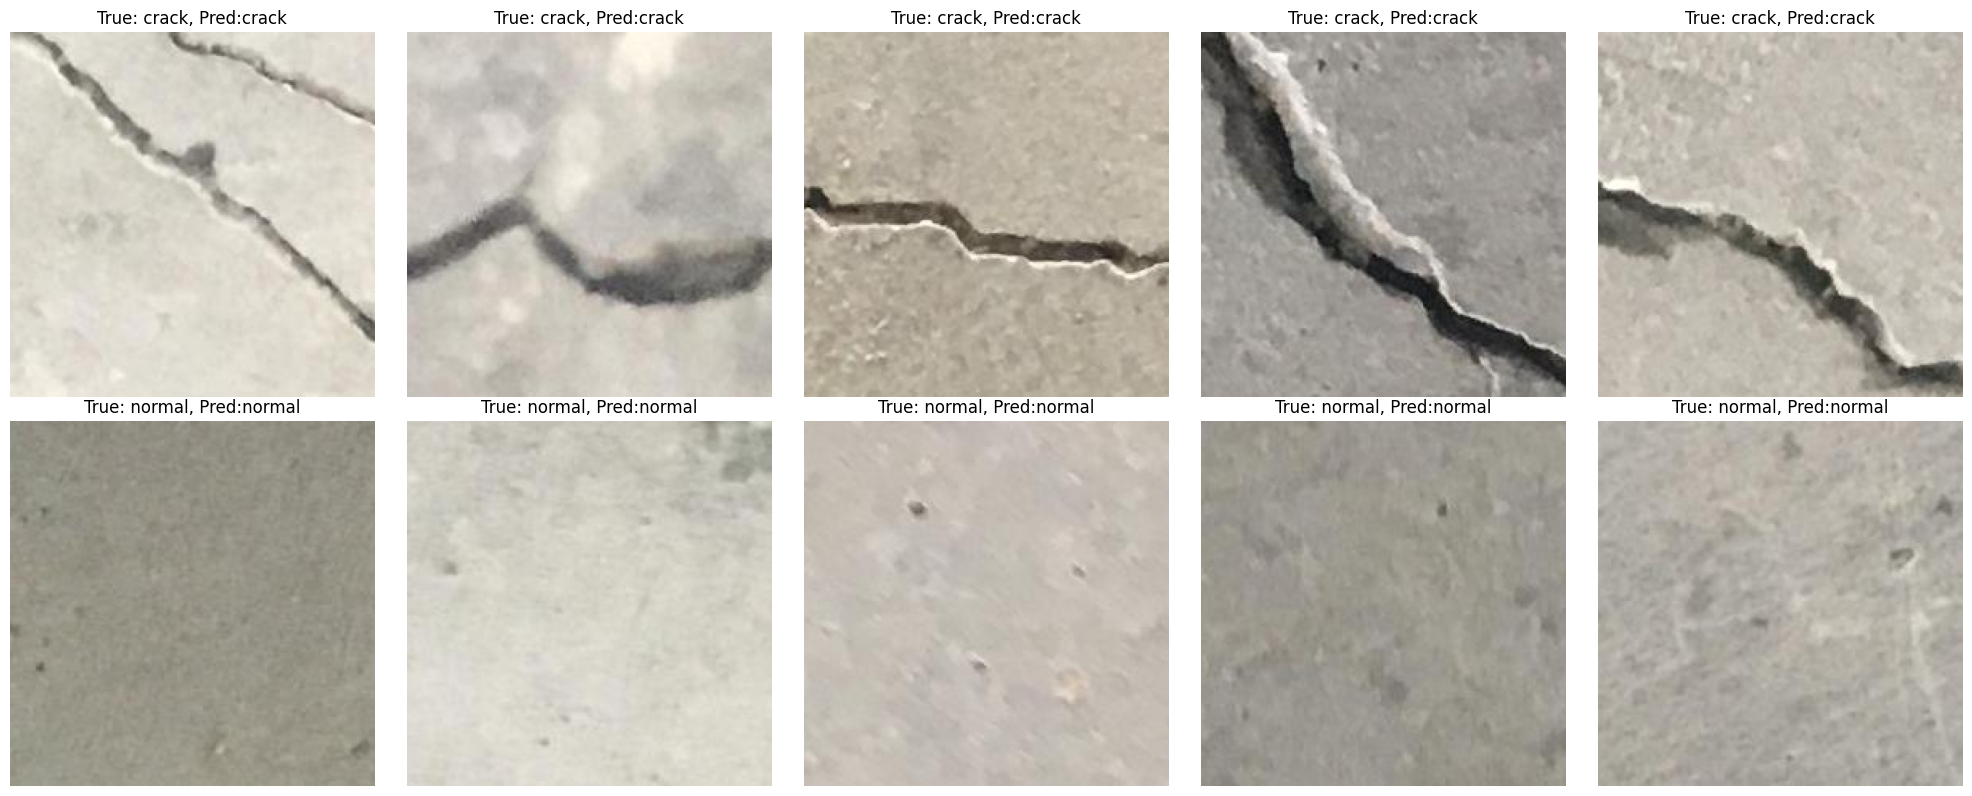

In [21]:
# 클래스별 폴더 경로
class_folders = {
    'crack': '/content/crack_dataset/3/test/crack',
    'normal': '/content/crack_dataset/3/test/normal'
}

plt.figure(figsize=(20, 8))
# subplot 인덱스를 위한 카운터
counter = 1

# 각 클래스별로 5장의 이미지 추론 및 시각화
for class_name, folder_path in class_folders.items():
  image_paths = glob.glob(os.path.join(folder_path, '*'))
  selected_paths = image_paths[:5] # 첫 5장 선택

  for image_path in selected_paths:
    image = load_and_transform_image(image_path, transform)

    net.eval() # 모델을 평가 모드로 설정
    # 모델을 사용한 추론
    with torch.no_grad():
      outputs = net(image)
      _, predicted = torch.max(outputs, 1)
    prediction = 'crack' if predicted.item() == 0 else 'normal'

    # 결과 시각화
    plt.subplot(2, 5, counter)
    plt.imshow(Image.open(image_path))
    plt.title(f'True: {class_name}, Pred:{prediction}')
    plt.axis('off')

    counter += 1

plt.tight_layout()
plt.show()